<a href="https://colab.research.google.com/github/johnjoseph004/AI-ML-internship/blob/main/day4_image_preprocessing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile
import os
import cv2

zip_path = "/content/archive (1).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 100


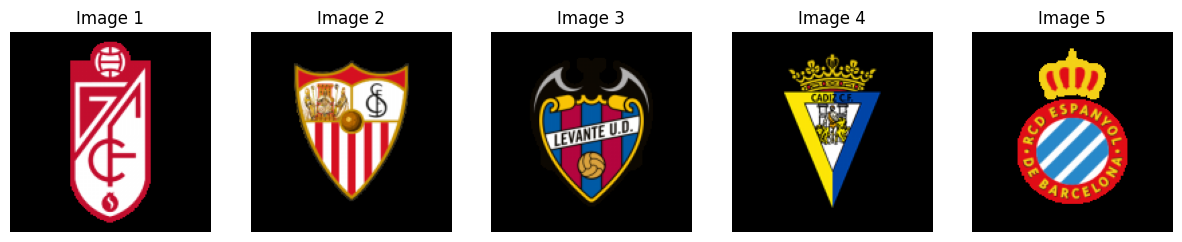

In [3]:
import matplotlib.pyplot as plt

# Display the first 5 images
plt.figure(figsize=(15, 5))
for i in range(min(5, len(images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    plt.title(f"Image {i+1}")
    plt.axis('off')
plt.show()

In [5]:
import pandas as pd

image_data = []

for idx, img in enumerate(images):
    height, width, channels = img.shape
    image_data.append({'Image Index': idx, 'Height': height, 'Width': width, 'Channels': channels})

image_info_df = pd.DataFrame(image_data)

print("Image Dimensions Summary:")
display(image_info_df.head())

Image Dimensions Summary:


,Image Index,Height,Width,Channels
0,0,150,150,3
1,1,150,150,3
2,2,150,150,3
3,3,150,150,3
4,4,150,150,3


In [6]:
resized_images = []
target_size = (224, 224)

for img in images:
    # Resize image to the target_size
    resized_img = cv2.resize(img, target_size)
    resized_images.append(resized_img)

images = resized_images

print(f"All images have been resized to {target_size[0]}x{target_size[1]} pixels.")
if len(images) > 0:
    print(f"Shape of the first resized image: {images[0].shape}")

All images have been resized to 224x224 pixels.
Shape of the first resized image: (224, 224, 3)


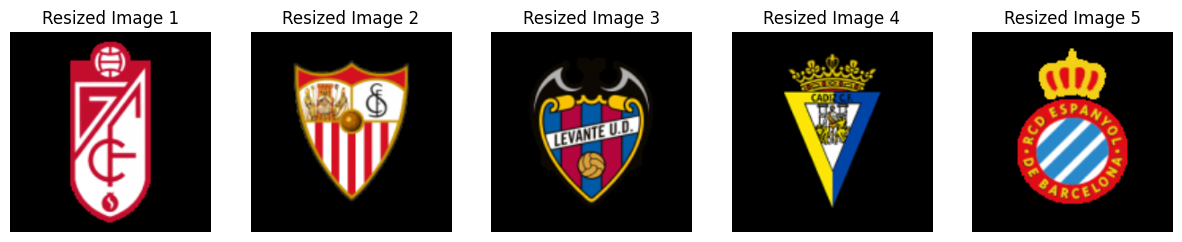

In [7]:
import matplotlib.pyplot as plt

# Display the first 5 resized images
plt.figure(figsize=(15, 5))
for i in range(min(5, len(images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
    plt.title(f"Resized Image {i+1}")
    plt.axis('off')
plt.show()

### Convert Images to RGB

In [8]:
rgb_images = []
for img in images:
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    rgb_images.append(rgb_img)

print(f"Total RGB images created: {len(rgb_images)}")
if len(rgb_images) > 0:
    print(f"Shape of the first RGB image: {rgb_images[0].shape}")

Total RGB images created: 100
Shape of the first RGB image: (224, 224, 3)


### Convert Images to Grayscale

In [9]:
gray_images = []
for img in images:
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_images.append(gray_img)

print(f"Total Grayscale images created: {len(gray_images)}")
if len(gray_images) > 0:
    print(f"Shape of the first Grayscale image: {gray_images[0].shape}")

Total Grayscale images created: 100
Shape of the first Grayscale image: (224, 224)


### Convert Images to HSV

In [18]:
hsv_images = []
for img in images:
    hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    hsv_images.append(hsv_img)

print(f"Total HSV images created: {len(hsv_images)}")
if len(hsv_images) > 0:
    print(f"Shape of the first HSV image: {hsv_images[0].shape}")

Total HSV images created: 100
Shape of the first HSV image: (224, 224, 3)


### Normalize Original Images (BGR) Pixel Values (0-255 to 0-1)

In [21]:
# Normalize the original 'images' (which are BGR by default from cv2.imread)
normalized_original_images = [img / 255.0 for img in images]
print(f"First original image (normalized) pixel value range: {normalized_original_images[0].min()} - {normalized_original_images[0].max()}")

First original image (normalized) pixel value range: 0.0 - 1.0


### Visualize First 5 RGB Images

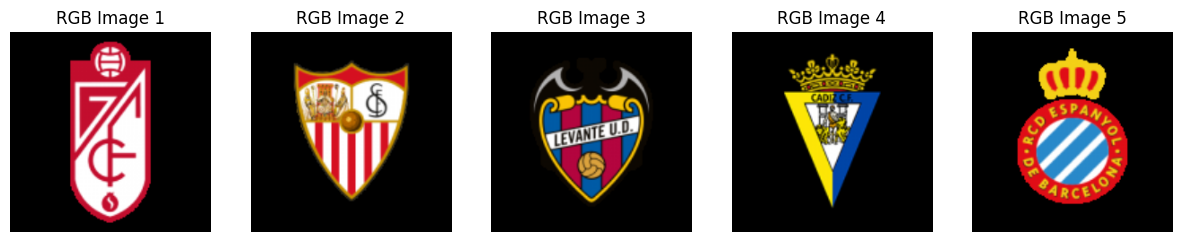

In [12]:
import matplotlib.pyplot as plt

# Display the first 5 RGB images
plt.figure(figsize=(15, 5))
for i in range(min(5, len(rgb_images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(rgb_images[i]) # RGB images are already in the correct format for matplotlib
    plt.title(f"RGB Image {i+1}")
    plt.axis('off')
plt.show()

### Visualize First 5 HSV Images

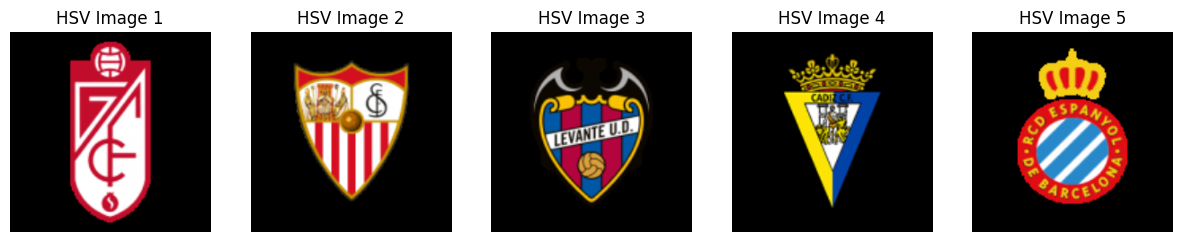

In [13]:
import matplotlib.pyplot as plt

# Display the first 5 HSV images
plt.figure(figsize=(15, 5))
for i in range(min(5, len(hsv_images))):
    plt.subplot(1, 5, i + 1)
    # Convert HSV back to RGB for proper display in matplotlib
    plt.imshow(cv2.cvtColor(hsv_images[i], cv2.COLOR_HSV2RGB))
    plt.title(f"HSV Image {i+1}")
    plt.axis('off')
plt.show()

### Visualize First 5 Grayscale Images

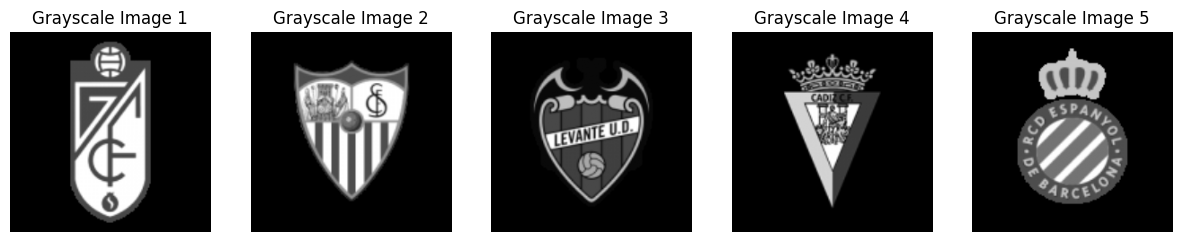

In [14]:
import matplotlib.pyplot as plt

# Display the first 5 Grayscale images
plt.figure(figsize=(15, 5))
for i in range(min(5, len(gray_images))):
    plt.subplot(1, 5, i + 1)
    plt.imshow(gray_images[i], cmap='gray') # Use cmap='gray' for grayscale images
    plt.title(f"Grayscale Image {i+1}")
    plt.axis('off')
plt.show()

### Display Individual Augmentations

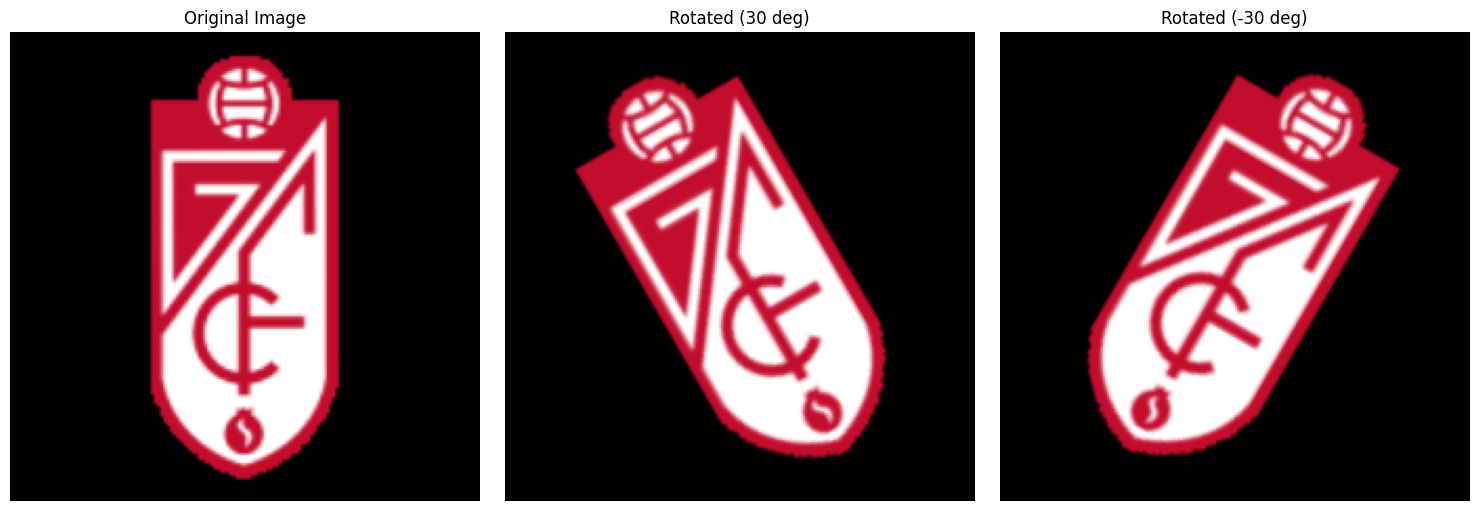

In [30]:
import matplotlib.pyplot as plt

# Choose the first original image for demonstration
demo_original_image = normalized_original_images[0]

# Convert to RGB for consistent display and processing in augmentation functions
demo_rgb_image = cv2.cvtColor((demo_original_image * 255).astype(np.uint8), cv2.COLOR_BGR2RGB) / 255.0

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(demo_rgb_image)
plt.title("Original Image")
plt.axis('off')

# --- Rotation Demonstration ---
rotated_image = rotate_image(demo_rgb_image, angle=30) # Rotate by 30 degrees
plt.subplot(1, 3, 2)
plt.imshow(rotated_image)
plt.title("Rotated (30 deg)")
plt.axis('off')

rotated_image_neg = rotate_image(demo_rgb_image, angle=-30) # Rotate by -30 degrees
plt.subplot(1, 3, 3)
plt.imshow(rotated_image_neg)
plt.title("Rotated (-30 deg)")
plt.axis('off')

plt.tight_layout()
plt.show()

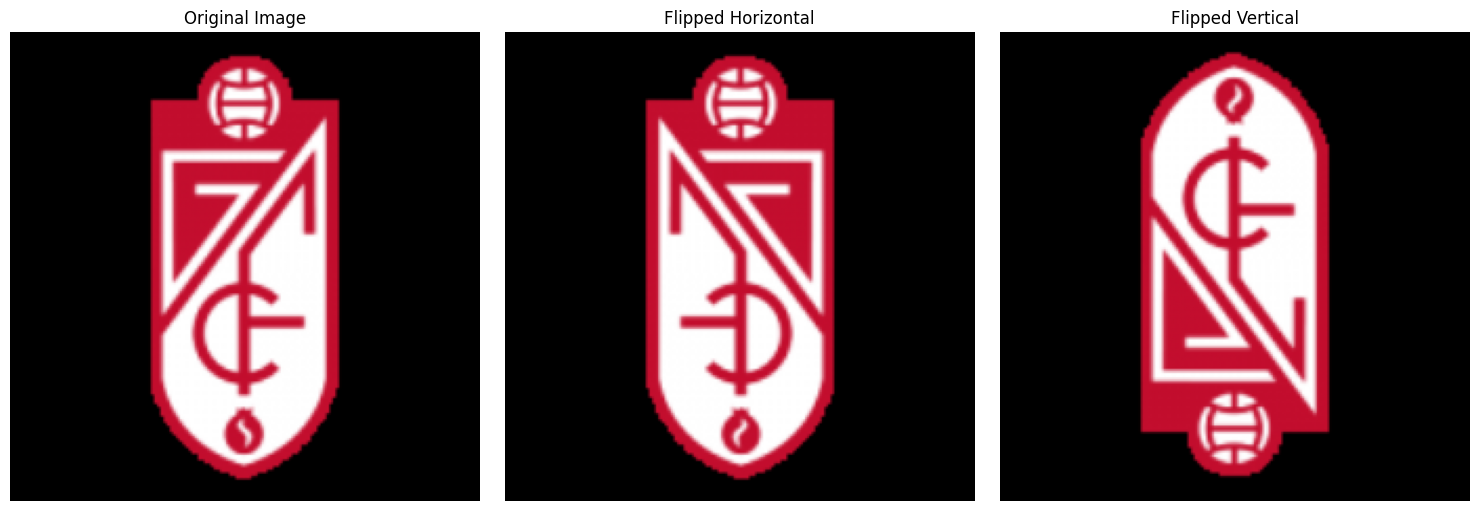

In [31]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(demo_rgb_image)
plt.title("Original Image")
plt.axis('off')

# --- Flip Demonstration ---
flipped_h_image = flip_image(demo_rgb_image, flip_code=1) # Horizontal flip
plt.subplot(1, 3, 2)
plt.imshow(flipped_h_image)
plt.title("Flipped Horizontal")
plt.axis('off')

flipped_v_image = flip_image(demo_rgb_image, flip_code=0) # Vertical flip
plt.subplot(1, 3, 3)
plt.imshow(flipped_v_image)
plt.title("Flipped Vertical")
plt.axis('off')

plt.tight_layout()
plt.show()

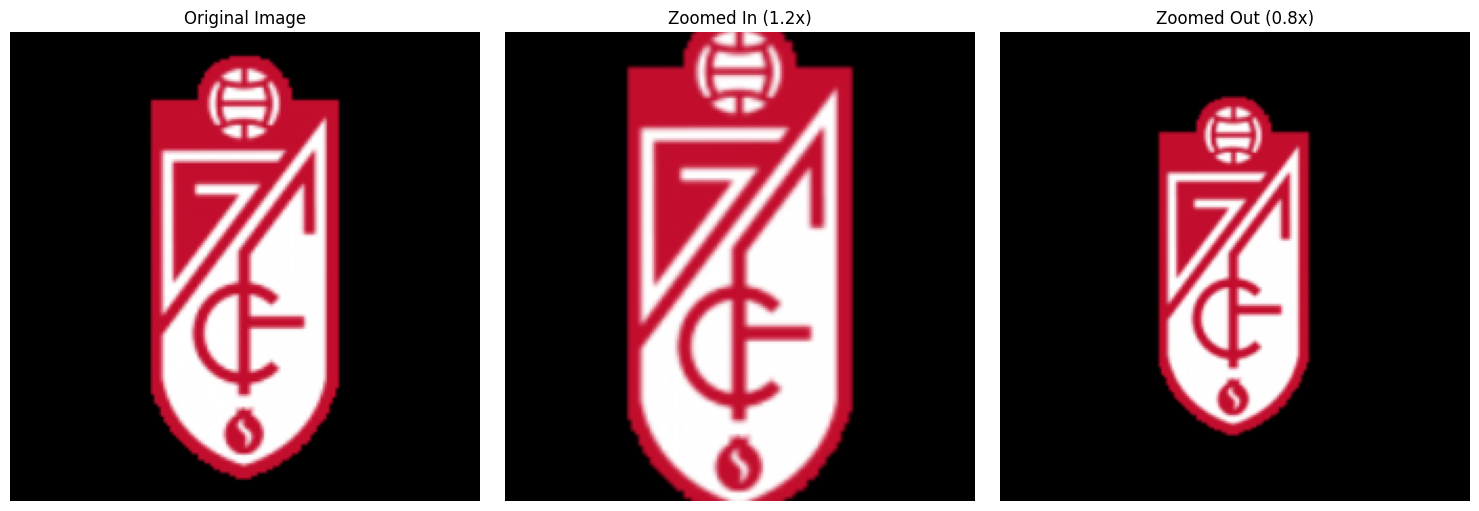

In [32]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(demo_rgb_image)
plt.title("Original Image")
plt.axis('off')

# --- Zoom Demonstration ---
zoomed_in_image = zoom_image(demo_rgb_image, zoom_factor=1.2) # Zoom in
plt.subplot(1, 3, 2)
plt.imshow(zoomed_in_image)
plt.title("Zoomed In (1.2x)")
plt.axis('off')

zoomed_out_image = zoom_image(demo_rgb_image, zoom_factor=0.8) # Zoom out
plt.subplot(1, 3, 3)
plt.imshow(zoomed_out_image)
plt.title("Zoomed Out (0.8x)")
plt.axis('off')

plt.tight_layout()
plt.show()

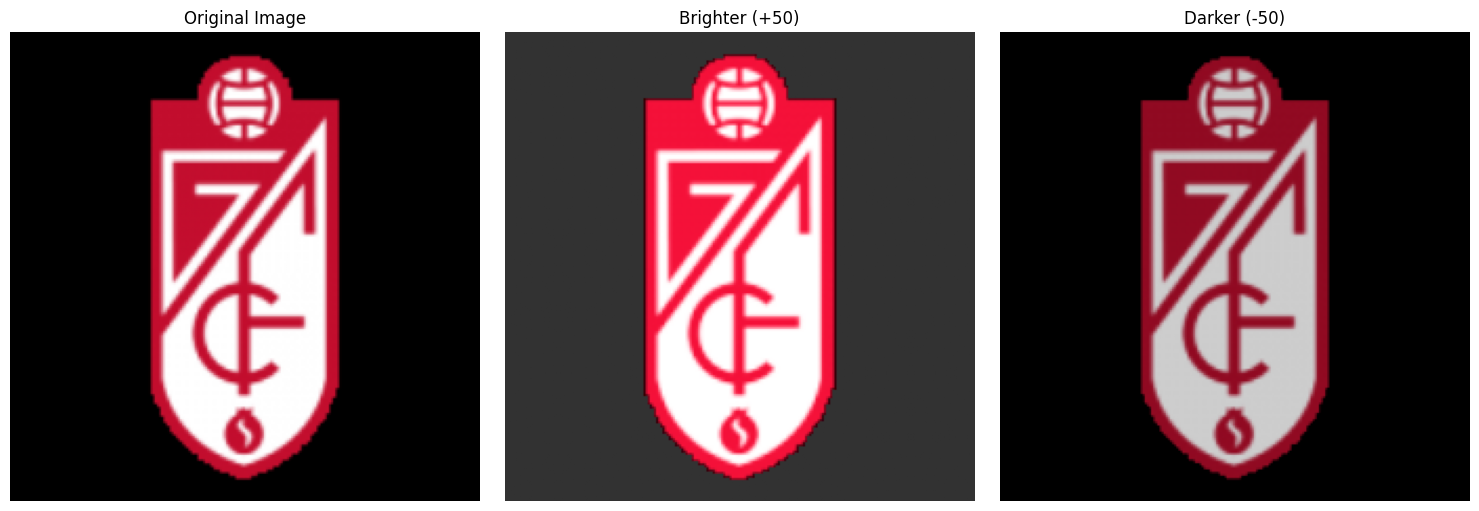

In [33]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(demo_rgb_image)
plt.title("Original Image")
plt.axis('off')

# --- Brightness Adjustment Demonstration ---
brighter_image = adjust_brightness(demo_rgb_image, value=50) # Brighter
plt.subplot(1, 3, 2)
plt.imshow(brighter_image)
plt.title("Brighter (+50)")
plt.axis('off')

darker_image = adjust_brightness(demo_rgb_image, value=-50) # Darker
plt.subplot(1, 3, 3)
plt.imshow(darker_image)
plt.title("Darker (-50)")
plt.axis('off')

plt.tight_layout()
plt.show()

### Create a Reusable `preprocess_image()` Function

In [34]:
def preprocess_image(image, target_size=(224, 224)):

    # Resize the image
    resized_img = cv2.resize(image, target_size)

    # Convert BGR to RGB
    rgb_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)

    # Normalize pixel values to 0-1
    normalized_img = rgb_img / 255.0

    return normalized_img

### Demonstrate `preprocess_image()` Function

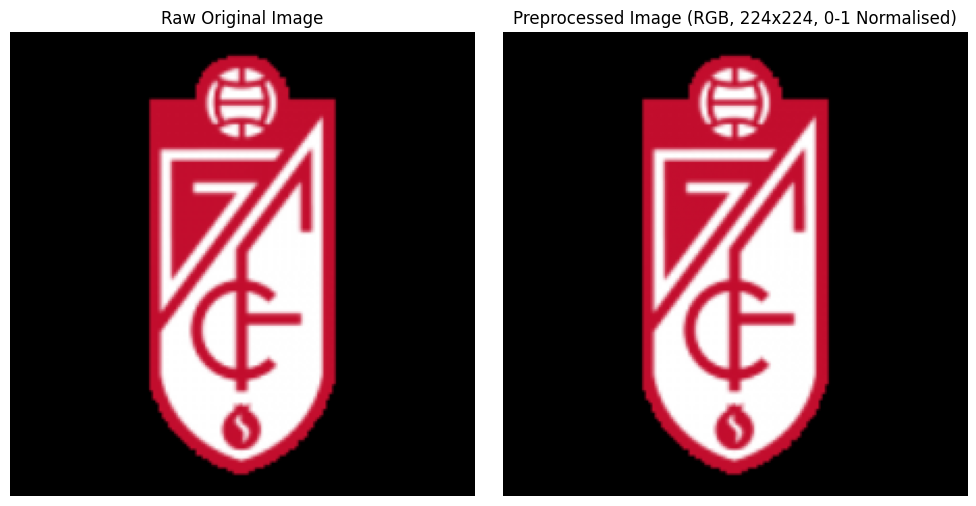

Shape of preprocessed image: (224, 224, 3)
Pixel value range of preprocessed image: 0.0 - 1.0


In [35]:
import matplotlib.pyplot as plt


raw_original_image = images[0]

# Preprocess the image using the new function
preprocessed_example_image = preprocess_image(raw_original_image)

# Display the original and preprocessed images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(raw_original_image, cv2.COLOR_BGR2RGB))
plt.title("Raw Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(preprocessed_example_image)
plt.title("Preprocessed Image (RGB, 224x224, 0-1 Normalised)")
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Shape of preprocessed image: {preprocessed_example_image.shape}")
print(f"Pixel value range of preprocessed image: {preprocessed_example_image.min()} - {preprocessed_example_image.max()}")